**Imports**

In [45]:
import pandas
import numpy as np
import matplotlib.pyplot as plt
from numba import njit, prange

# Computing the two-point correlation function

**Task 5**

In [46]:
# Reading in the data and subsequentially cutting out a redshift range and diving between red and blue galaxies according to color.
data = pandas.read_csv('sdss_cutout.csv')
z = data['Z'].values
z_mask = (z > 0.08) & (z < 0.12)
data = data[z_mask].reset_index(drop=True)

# Computing the color of the galaxies and dividing them into red and blue populations according to the color cut at 2.3.
u_mag = data['phot_u'].values
r_mag = data['phot_r'].values
color = u_mag - r_mag
red_gal = data[color > 2.3].reset_index(drop=True)
blue_gal = data[color <= 2.3].reset_index(drop=True)

# Reading out the RA and DEC values from the two populations.
red_gal_ra = red_gal['RA'].values
red_gal_dec = red_gal['DEC'].values

blue_gal_ra = blue_gal['RA'].values
blue_gal_dec = blue_gal['DEC'].values

In [47]:
# Since the red and blue samples have different sized we need to create our random samples with matching sizes.
red_len = len(red_gal)
blue_len = len(blue_gal)

# According to the NumPy documentation, this is the recommended way to create a sample from a uniform distribution.
rand = np.random.default_rng()

red_ra_rand = rand.uniform(130, 230, red_len)
red_dec_rand = rand.uniform(5, 65, red_len)

blue_ra_rand = rand.uniform(130, 230, blue_len)
blue_dec_rand = rand.uniform(5, 65, blue_len)

omega_bins = np.geomspace(0.003, 0.3, 11)

In [48]:
# To later use the formula for ω we need to convert our coordinates into spherical ones.
def ra_dec_to_spherical(ra, dec):
    """Convert RA/DEC angles from degrees to spherical coordinates.

    Parameters
    ----------
    ra : array_like
        Right ascension values in degrees.
    dec : array_like
        Declination values in degrees.

    Returns
    -------
    phi : ndarray
        Azimuthal spherical angle in radians.
    theta : ndarray
        Polar spherical angle in radians.
    """
    phi = np.pi * (ra/180)
    theta = np.pi/2 - np.pi * (dec/180)
    return phi, theta

In [49]:
# Conversion

red_phi, red_theta = ra_dec_to_spherical(red_gal_ra, red_gal_dec)
blue_phi, blue_theta = ra_dec_to_spherical(blue_gal_ra, blue_gal_dec)

red_phi_rand, red_theta_rand = ra_dec_to_spherical(red_ra_rand, red_dec_rand)
blue_phi_rand, blue_theta_rand = ra_dec_to_spherical(blue_ra_rand, blue_dec_rand)

In [50]:
# The main function to calculate the two point correlation function. We use it to count how many galaxy pairs fall inside each of the angular separation bins we defined according to the exercise sheet earlier.
@njit(parallel=True)
def count_pairs(delta1, delta2, alpha1, alpha2, edges, auto=False):
    """Count object pairs in angular separation bins.

    Parameters
    ----------
    delta1 : array_like
        First set of declination angles (theta) in radians.
    delta2 : array_like
        Second set of declination angles (theta) in radians.
    alpha1 : array_like
        First set of right ascension angles (phi) in radians.
    alpha2 : array_like
        Second set of right ascension angles (phi) in radians.
    edges : array_like
        Bin edges for angular separations (omega), in radians.
    auto : bool, optional
        If True, compute auto-correlation (i<j only) within one sample.
        If False, compute cross-correlation (all pairs).

    Returns
    -------
    counts : ndarray
        Pair counts in each angular separation bin.
    """
    bin_num = len(edges) - 1
    counts = np.zeros(bin_num, dtype=np.int64)

    for i in prange(len(alpha1)):
        cos_a = np.cos(alpha1[i])
        sin_a = np.sin(alpha1[i])
        delta = delta1[i]

        j_start = i + 1 if auto else 0

        for j in range(j_start, len(alpha2)):
            cos_omega = (cos_a * np.cos(alpha2[j]) + np.cos(delta - delta2[j]) * sin_a * np.sin(alpha2[j]))

            # Without the clamp we get quite a lot of NaNs in our results. Possibly due to floating point errors.
            if cos_omega > 1.0:
                cos_omega = 1.0
            elif cos_omega < -1.0:
                cos_omega = -1.0

            omega = np.arccos(cos_omega)

            for k in range(bin_num):
                if edges[k] <= omega < edges[k + 1]:
                    counts[k] += 1
                    break
    return counts

In [51]:
red_DD = count_pairs(red_phi, red_phi, red_theta, red_theta, omega_bins, auto=True)
red_RR = count_pairs(red_phi_rand, red_phi_rand, red_theta_rand, red_theta_rand, omega_bins, auto=True)
red_DR = count_pairs(red_phi, red_phi_rand, red_theta, red_theta_rand, omega_bins, auto=False)

In [52]:
blue_DD = count_pairs(blue_phi, blue_phi, blue_theta, blue_theta, omega_bins, auto=True)
blue_RR = count_pairs(blue_phi_rand, blue_phi_rand, blue_theta_rand, blue_theta_rand, omega_bins, auto=True)
blue_DR = count_pairs(blue_phi, blue_phi_rand, blue_theta, blue_theta_rand, omega_bins, auto=False)

In [53]:
bin_mids = np.sqrt(omega_bins[:-1] * omega_bins[1:])
pandas.DataFrame({
    'DD': red_DD,
    'RR': red_RR,
    'DR': red_DR,
}, index=pandas.Index(bin_mids, name='θ [rad]'))

,DD,RR,DR
θ [rad],,,
0.003777,99951,57589,107101
0.005986,216048,144511,269453
0.009487,481205,362230,671790
0.015036,1100934,902994,1674563
0.023830,2561785,2237092,4154822
0.037768,5948224,5517799,10227427
0.059858,13617519,13428799,24873046
0.094868,30526215,32077252,59318194
0.150356,67345273,73771694,137381037


In [54]:
bin_mids = np.sqrt(omega_bins[:-1] * omega_bins[1:])
pandas.DataFrame({
    'DD': blue_DD,
    'RR': blue_RR,
    'DR': blue_DR,
}, index=pandas.Index(bin_mids, name='θ [rad]'))

,DD,RR,DR
θ [rad],,,
0.003777,19100,14817,27256
0.005986,44922,36490,67517
0.009487,106500,91196,169569
0.015036,255802,227526,424690
0.023830,605757,565507,1058546
0.037768,1438746,1397433,2620940
0.059858,3391397,3396337,6408301
0.094868,7808695,8117132,15332705
0.150356,17407528,18615694,35577406


In [55]:
def landy_szalay(DD, RR, DR, num):
    """Compute the Landy-Szalay estimator for the two-point correlation function.

    Parameters
    ----------
    DD : array_like
        Data-Data pair counts per bin.
    RR : array_like
        Random-Random pair counts per bin.
    DR : array_like
        Data-Random pair counts per bin.
    num : int
        Number of data objects in the sample.

    Returns
    -------
    xi : ndarray
        Estimated correlation function values per bin.
    """
    return 1 + DD/RR - (num -1)/num * DR/RR

In [56]:
red_xi = landy_szalay(red_DD, red_RR, red_DR, red_len)
blue_xi = landy_szalay(blue_DD, blue_RR, blue_DR, blue_len)

bin_mids = np.sqrt(omega_bins[:-1] * omega_bins[1:])
pandas.DataFrame({
    'ξ Red': red_xi,
    'ξ Blue': blue_xi,
}, index=pandas.Index(bin_mids, name='θ [rad]'))

,ξ Red,ξ Blue
θ [rad],,
0.003777,0.875875,0.449612
0.005986,0.630474,0.380850
0.009487,0.473887,0.308485
0.015036,0.364778,0.257781
0.023830,0.287929,0.199383
0.037768,0.224503,0.154086
0.059858,0.161867,0.111780
0.094868,0.102448,0.073132
0.150356,0.050672,0.024011


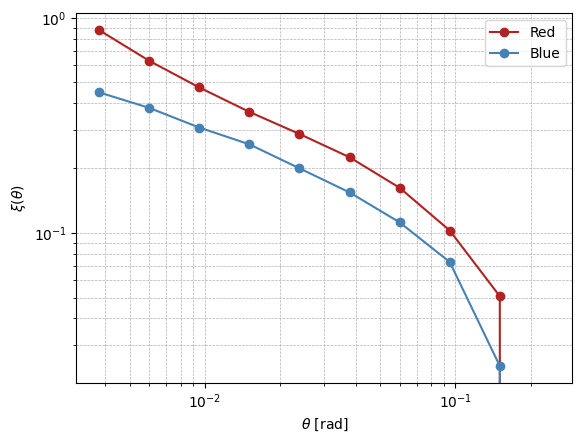

In [57]:
# We need to compute the geometric mean first. We can't use the arithmic mean since our bins are log spaced.
bin_midpoints = np.sqrt(omega_bins[:-1] * omega_bins[1:])
#degree_points = np.degrees(bin_midpoints)
plt.loglog(bin_midpoints, red_xi, 'o-', c='firebrick', label='Red',)
plt.loglog(bin_midpoints, blue_xi, 'o-', c='steelblue', label='Blue')
plt.grid(True, which='both', ls='--', lw=0.5)
plt.xlabel(r'$\theta$ [rad]')
plt.ylabel(r'$\xi(\theta)$')
plt.legend()
plt.show()

**Task 6**

In [58]:
jack_knife_regions = 6
# We only slice the data in the RA direction to save on computation time. Once could also divide into squares in the RA-DEC plane, but that would require more computation time.
ra_edges = np.linspace(130, 230, jack_knife_regions + 1)

red_region = np.digitize(red_gal_ra, ra_edges[1:-1])
red_region_rand = np.digitize(red_ra_rand, ra_edges[1:-1])

blue_region = np.digitize(blue_gal_ra, ra_edges[1:-1])
blue_region_rand = np.digitize(blue_ra_rand, ra_edges[1:-1])

red_xi_samples = []
blue_xi_samples = []

In [59]:
def jackknife_xi(phi, theta, phi_rand, theta_rand, region, region_rand, omega_bins, n_regions):
    """Compute jackknife estimates of xi from data and random catalogs.

    Parameters
    ----------
    phi, theta : ndarray
        Data spherical angles (phi, theta) in radians.
    phi_rand, theta_rand : ndarray
        Random spherical angles (phi, theta) in radians.
    region, region_rand : ndarray
        Region labels for data and random points.
    omega_bins : ndarray
        Angular bin edges for pair counting.
    n_regions : int
        Number of jackknife regions.

    Returns
    -------
    xi_samples : ndarray
        Jackknife sample xi estimates for each left-out region.
    """
    xi_samples = []

    for k in range(n_regions):
        mask = region != k
        mask_rand = region_rand != k

        DD_k = count_pairs(phi[mask], phi[mask], theta[mask], theta[mask], omega_bins, auto=True)
        RR_k = count_pairs(phi_rand[mask_rand], phi_rand[mask_rand], theta_rand[mask_rand], theta_rand[mask_rand], omega_bins, auto=True)
        DR_k = count_pairs(phi[mask], phi_rand[mask_rand], theta[mask], theta_rand[mask_rand], omega_bins, auto=False)

        xi_k = landy_szalay(DD_k, RR_k, DR_k, np.sum(mask))
        xi_samples.append(xi_k)

    return np.array(xi_samples)

red_xi_all = jackknife_xi(red_phi, red_theta, red_phi_rand, red_theta_rand, red_region, red_region_rand, omega_bins, jack_knife_regions)
blue_xi_all = jackknife_xi(blue_phi, blue_theta, blue_phi_rand, blue_theta_rand, blue_region, blue_region_rand, omega_bins, jack_knife_regions)

In [60]:
bin_mids = np.sqrt(omega_bins[:-1] * omega_bins[1:])
col_idx = pandas.Index(bin_mids, name='θ [rad]')
jk_idx = [f'Sample {k+1}' for k in range(jack_knife_regions)]

display(pandas.DataFrame(red_xi_all, index=jk_idx, columns=col_idx).style.set_caption('Red Jackknife Samples'))
display(pandas.DataFrame(blue_xi_all, index=jk_idx, columns=col_idx).style.set_caption('Blue Jackknife Samples'))

red_xi_mean = np.mean(red_xi_all, axis=0)
red_xi_std = np.std(red_xi_all, axis=0)

blue_xi_mean = np.mean(blue_xi_all, axis=0)
blue_xi_std = np.std(blue_xi_all, axis=0)

# From the equation in the lecture.
red_xi_var = ((jack_knife_regions - 1) / jack_knife_regions) * np.sum((red_xi_all - red_xi_mean)**2, axis=0)
red_xi_err = np.sqrt(red_xi_var)

blue_xi_var = ((jack_knife_regions - 1) / jack_knife_regions) * np.sum((blue_xi_all - blue_xi_mean)**2, axis=0)
blue_xi_err = np.sqrt(blue_xi_var)

pandas.DataFrame({
    'σ Red': red_xi_err,
    'σ Blue': blue_xi_err,
}, index=col_idx)

θ [rad],0.003777,0.005986,0.009487,0.015036,0.023830,0.037768,0.059858,0.094868,0.150356,0.238298
Sample 1,0.890459,0.640087,0.470759,0.362673,0.286085,0.226954,0.164876,0.105325,0.051608,-0.051851
Sample 2,0.897134,0.644895,0.484676,0.373360,0.288993,0.220337,0.153902,0.084148,0.026671,-0.056675
Sample 3,0.852805,0.613819,0.466180,0.356114,0.283335,0.216824,0.160011,0.106155,0.051663,-0.030983
Sample 4,0.924376,0.670985,0.511987,0.403008,0.319935,0.250874,0.181251,0.114214,0.056443,-0.031668
Sample 5,0.912203,0.652770,0.493287,0.381062,0.303219,0.239225,0.170742,0.102204,0.045136,-0.048660
Sample 6,0.784245,0.564741,0.421112,0.319200,0.246968,0.190301,0.130622,0.067859,0.028172,-0.052812


θ [rad],0.003777,0.005986,0.009487,0.015036,0.023830,0.037768,0.059858,0.094868,0.150356,0.238298
Sample 1,0.461450,0.392789,0.312110,0.261833,0.199260,0.151753,0.111053,0.069035,0.023067,-0.073741
Sample 2,0.444055,0.375865,0.310392,0.256204,0.198242,0.151860,0.106684,0.061332,0.020375,-0.043865
Sample 3,0.429696,0.364531,0.294508,0.248390,0.192300,0.148450,0.110605,0.077044,0.030381,-0.041177
Sample 4,0.471246,0.403099,0.323804,0.274442,0.215864,0.167961,0.124487,0.083239,0.034464,-0.045336
Sample 5,0.455693,0.376474,0.319457,0.265258,0.210059,0.164000,0.118530,0.072541,0.023345,-0.065221
Sample 6,0.433750,0.372421,0.290803,0.238982,0.179195,0.136565,0.094433,0.060772,0.011937,-0.076951


,σ Red,σ Blue
θ [rad],,
0.003777,0.105115,0.033213
0.005986,0.076559,0.029139
0.009487,0.063213,0.027077
0.015036,0.057370,0.025716
0.023830,0.049678,0.026526
0.037768,0.042458,0.023046
0.059858,0.035245,0.021052
0.094868,0.035239,0.018026
0.150356,0.026148,0.016076


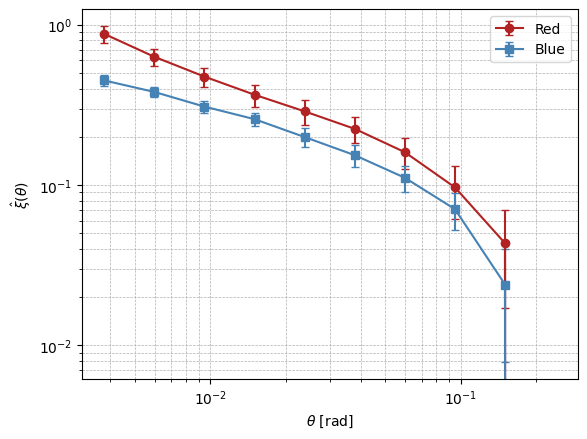

In [61]:
fig, ax = plt.subplots()

ax.errorbar(bin_midpoints, red_xi_mean, yerr=red_xi_err, fmt='o-', c='firebrick', capsize=3, label='Red')
ax.errorbar(bin_midpoints, blue_xi_mean, yerr=blue_xi_err, fmt='s-', c='steelblue', capsize=3, label='Blue')

ax.grid(True, which='both', ls='--', lw=0.5)

ax.set_xscale('log')
ax.set_yscale('log')
ax.set_xlabel(r'$\theta$ [rad]')
ax.set_ylabel(r'$\hat{\xi}(\theta)$')
#ax.set_title('2PCF with Jackknife Error Bars')
ax.legend()
plt.show()